In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the dataset
df = pd.read_csv('heart-cleaned.csv')

# 2. Separate features (X) and target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# 3. Define which columns are categorical and which are numerical
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# 4. Create a preprocessing pipeline
# SVM is very sensitive to scale, so numerical features must be scaled.
# Categorical features need to be converted to numbers (One-Hot Encoding).
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 5. Create the full pipeline with the SVM Classifier
# We use a Pipeline to bundle preprocessing and modeling steps.
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', random_state=42))
])

# 6. Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train the model
svm_pipeline.fit(X_train, y_train)

# 8. Make predictions
y_pred = svm_pipeline.predict(X_test)

# 9. Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        71
           1       0.92      0.89      0.90        79

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150



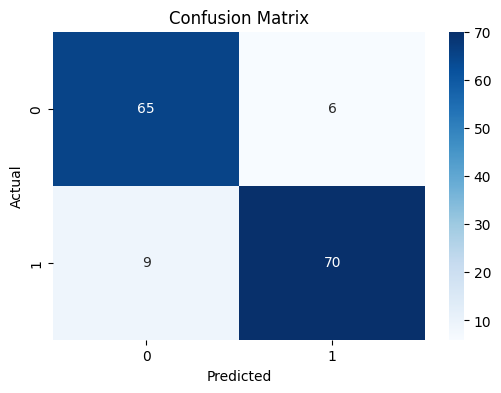

<Figure size 600x400 with 0 Axes>

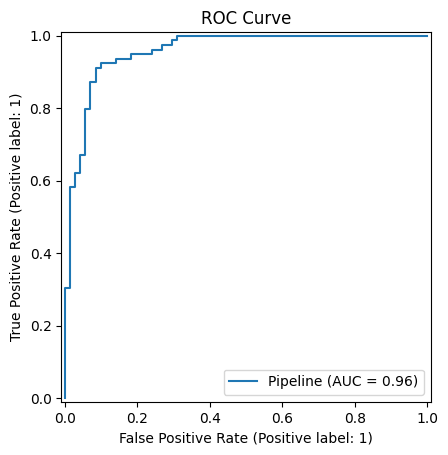

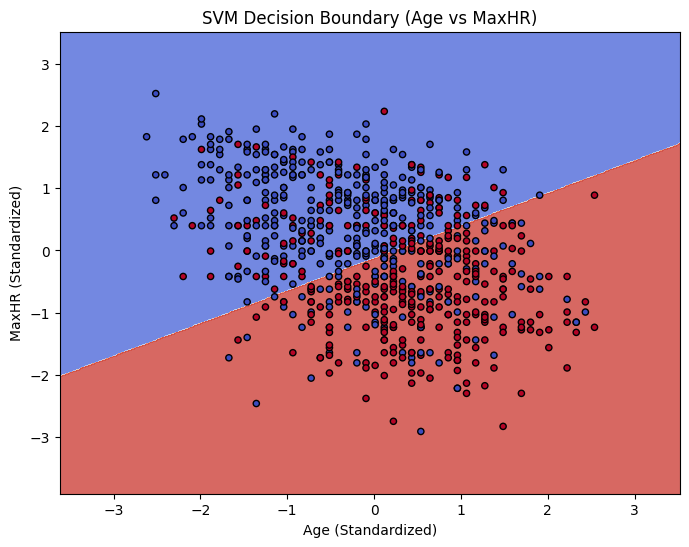

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, RocCurveDisplay

# Load data
df = pd.read_csv('heart-cleaned.csv')
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# --- Full Model for Confusion Matrix & ROC ---
# Setup preprocessing
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', probability=True, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# 1. Confusion Matrix
y_pred = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')

# 2. ROC Curve
plt.figure(figsize=(6, 4))
RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
plt.title('ROC Curve')
plt.savefig('roc_curve.png')

# --- Simplified 2D Model for Decision Boundary Visualization ---
# We pick 2 features to visualize the "Line" SVM draws
feature_x = 'Age'
feature_y = 'MaxHR'
X_2d = df[[feature_x, feature_y]].values
y_2d = df['HeartDisease'].values

# Scale the data (SVM requires scaling)
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Fit a 2D SVM
svm_2d = SVC(kernel='linear')
svm_2d.fit(X_2d_scaled, y_2d)

# Generate grid for plotting
h = .02 
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
plt.xlabel(f'{feature_x} (Standardized)')
plt.ylabel(f'{feature_y} (Standardized)')
plt.title(f'SVM Decision Boundary ({feature_x} vs {feature_y})')
plt.savefig('svm_decision_boundary.png')